In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### SRI Candidate Variable Catalog & Data Source Reference

This table inventories the candidate variables evaluated during the Exploratory Data Analysis (EDA) phase. It includes all structural socioeconomic income brackets, behavioral traits, and clinical outcomes compiled from the local SQLite database (`data/stroke_burden.db`) prior to feature trimming and PCA index generation.

| Variable Name | Category | Description | Data Source | Notes / Action Item |
|---|---|---|---|---|
| `acute_stroke_mortality_per_100k` | Clinical Outcome | **Primary Validation Target** - Age-adjusted mortality rate per 100,000 for sudden, acute stroke (ICD-10 I60–I66). | CDC WONDER (2018–2024 Pooled) | **Withhold from Index.** Used as ground-truth target to validate final SRI/SCAI predictability. |
| `sequelae_stroke_mortality_per_100k`| Clinical Outcome | **Secondary Validation Target** - Age-adjusted mortality rate per 100,000 for chronic stroke sequelae/late effects (ICD-10 I69). | CDC WONDER (2018–2024 Pooled) | **Withhold from Index.** Evaluates long-term care, secondary prevention, and rehabilitation deficits. |
| `stroke_prevalence` | Clinical Outcome | **SRI Input Feature** - % of living adults who have ever been diagnosed as having experienced a stroke. | CDC PLACES (2023 data released in 2025) | **Keep.** Tracks baseline biological and historical disease burden within the community. |
| `pop_density` | Demographic | Population density (people per sq. mile) | Census TIGER + ACS | Check skewness for extreme urban outliers |
| `pcnt_65_plus` | Demographic | % of population aged 65 and older | ACS 5-year estimates (2023) | Core biological risk factor |
| `poverty_rate` | Socioeconomic | % of individuals living below the federal poverty line | ACS 5-year estimates (2023) | Continuous economic distress baseline |
| `pcnt_low_income` | Socioeconomic | % of population falling into the low-income bracket | ACS 5-year estimates (2023) | Represents structural deficit; **Keep for SRI** |
| `pcnt_middle_class` | Socioeconomic | % of population falling into the middle-income bracket | ACS 5-year estimates (2023) | Explore for collinearity audit; *Omit from SRI* |
| `pcnt_upper_class` | Socioeconomic | % of population falling into the upper-income bracket | ACS 5-year estimates (2023) | Explore for collinearity audit; *Omit from SRI* |
| `pcnt_bachelors` | Socioeconomic | % of adults with a Bachelor's degree or higher | ACS 5-year estimates (2023) | Protective factor; Must be `flip` aligned |
| `smoking_prevalence` | Behavioral | % of adults who currently smoke cigarettes | CDC PLACES (2023 data released in 2025) | Modifiable behavioral health risk |
| `physical_inactivity` | Behavioral | % of adults with no leisure-time physical activity | CDC PLACES (2023 data released in 2025) | Modifiable behavioral health risk |
| `obesity_prevalence` | Clinical Outcome | % of adults with a Body Mass Index (BMI) greater than 30$ | CDC PLACES (2023 data released in 2025) | Chronic metabolic condition |
| `diabetes_prevalence` | Clinical Outcome | % of adults with diagnosed diabetes mellitus | CDC PLACES (2023 data released in 2025) | Chronic metabolic condition |
| `hypertension_prevalence`| Clinical Outcome | % of adults with diagnosed high blood pressure | CDC PLACES (2023 data released in 2025) | Key physiological precursor to stroke |
| `high_chol_prevalence` | Clinical Outcome | % of adults with diagnosed high cholesterol levels | CDC PLACES (2023 data released in 2025) | Key physiological precursor to stroke |
| `binge_drinking_prev` | Behavioral | % of adults reporting recent binge drinking episodes | CDC PLACES (2023 data released in 2025) | Modifiable behavioral health risk |

---

*Note: In addition to these SRI feature candidates, the baseline validation target used throughout the EDA notebook is **`acute_stroke_mortality_per_100k`**, drawn from multi-year pooled (2018–2024) CDC WONDER mortality records.*

## DATA EXTRACTION

In [2]:
# Start from the current file/notebook location and look upwards for the root folder
current_dir = Path.cwd()
repo_root = next((p for p in [current_dir] + list(current_dir.parents) if p.name == "stroke-burden-index"), Path.cwd())

if repo_root is None:
    raise FileNotFoundError("Could not find the 'stroke-burden-index' root directory.")

# Build the absolute path to the database file
db_path = repo_root / "data" / "stroke_burden.db"

In [3]:
# Connect and execute SRI variable query
conn = sqlite3.connect(str(db_path))

query = """
SELECT 
    fips, county, state,
    acute_stroke_mortality_per_100k,
    sequelae_stroke_mortality_per_100k,
    pop_density, pcnt_65_plus, poverty_rate, pcnt_low_income, pcnt_middle_class, pcnt_upper_class, pcnt_bachelors,
    smoking_prevalence, obesity_prevalence, diabetes_prevalence, physical_inactivity,
    hypertension_prevalence, high_cholesterol_prevalence, binge_drinking_prevalence, stroke_prevalence
FROM master;
"""

df = pd.read_sql_query(query, conn)
conn.close()

In [4]:
df.head(2)

,fips,county,state,acute_stroke_mortality_per_100k,sequelae_stroke_mortality_per_100k,pop_density,pcnt_65_plus,poverty_rate,pcnt_low_income,pcnt_middle_class,pcnt_upper_class,pcnt_bachelors,smoking_prevalence,obesity_prevalence,diabetes_prevalence,physical_inactivity,hypertension_prevalence,high_cholesterol_prevalence,binge_drinking_prevalence,stroke_prevalence
0,36001,Albany,NY,11.60,1.36,605.60,17.8,12.9,29.9,39.1,12.1,41.6,10.5,29.8,9.2,21.2,31.7,34.9,18.4,3.0
1,36003,Allegany,NY,15.49,3.65,45.31,19.7,16.8,40.2,39.1,4.1,21.0,13.8,34.4,11.1,25.5,35.5,37.8,17.4,3.7


In [5]:
# Enforce zero-padded 5-character string data contract for FIPS codes
df['fips'] = df['fips'].astype(str).str.zfill(5)

print(f"Successfully loaded {len(df)} Tri-State counties (NY, NJ, CT).")
print(f"Columns extracted: {df.shape[1]}")
df.tail(3)

Successfully loaded 91 Tri-State counties (NY, NJ, CT).
Columns extracted: 20


,fips,county,state,acute_stroke_mortality_per_100k,sequelae_stroke_mortality_per_100k,pop_density,pcnt_65_plus,poverty_rate,pcnt_low_income,pcnt_middle_class,pcnt_upper_class,pcnt_bachelors,smoking_prevalence,obesity_prevalence,diabetes_prevalence,physical_inactivity,hypertension_prevalence,high_cholesterol_prevalence,binge_drinking_prevalence,stroke_prevalence
88,09011,New London,CT,16.97,2.51,403.80,19.7,9.2,27.7,39.5,13.8,34.3,10.4,31.9,9.7,25.2,34.7,36.3,15.270420,3.2
89,09013,Tolland,CT,9.24,1.56,365.02,17.9,8.5,24.4,37.4,18.3,37.5,9.7,30.4,8.2,19.8,29.3,36.5,15.588377,2.8
90,09015,Windham,CT,14.51,2.09,226.97,18.2,11.3,29.4,40.5,9.8,23.2,13.5,34.0,10.7,28.3,34.7,37.1,16.177997,3.4


# EDA

In [6]:
all_features = [
    'pop_density', 'pcnt_65_plus', 'poverty_rate', 'pcnt_low_income', 
    'pcnt_middle_class', 'pcnt_upper_class', 'pcnt_bachelors',
    'smoking_prevalence', 'obesity_prevalence', 'diabetes_prevalence', 'physical_inactivity',
    'hypertension_prevalence', 'high_cholesterol_prevalence', 'binge_drinking_prevalence', 'stroke_prevalence'
]

## Check for Scales and Spreads

In [7]:
print("\nSummary Statistics:")
print(df[all_features].describe().T[['mean', 'std', 'min', 'max']])


Summary Statistics:
                                    mean          std    min       max
pop_density                  2697.841648  9197.057077   2.96  70502.82
pcnt_65_plus                   19.170330     3.119918  12.40     32.80
poverty_rate                   11.956044     3.758552   3.80     26.90
pcnt_low_income                31.570330     7.448751  14.90     50.80
pcnt_middle_class              37.802198     2.733332  28.20     42.90
pcnt_upper_class               12.743956     8.014434   3.60     33.40
pcnt_bachelors                 31.780220     9.988763  16.70     61.20
smoking_prevalence             12.492308     2.169804   8.20     16.50
obesity_prevalence             31.860440     4.186775  19.20     41.80
diabetes_prevalence            11.027473     1.282018   7.60     16.10
physical_inactivity            25.370330     3.228398  17.90     38.10
hypertension_prevalence        34.279121     2.827111  26.10     41.50
high_cholesterol_prevalence    38.143956     2.267069  2

Percentage-based features are clean and bounded tightly between 2.4% and 61.2%, meaning they share a highly compatible scale. Conversely, `pop_density` operates on an entirely different magnitude, with a standard deviation (9,197) that vastly exceeds its mean (2,697).

***RECOMMENDATION***: When checking for data distribution, `pop_density` should be separated from the other features because its massive maximum value (70,502 people per square mile) acts as an extreme regional outlier. If plotted on the same axis, this variable would completely compress the 0–100% scale of the other 14 features.

## Check for Skewness and Outliers

In [8]:
# Run the following lines to save graphs to outputs folder
# output_dir = repo_root / "outputs"
# output_dir.mkdir(exist_ok=True)

### Population density

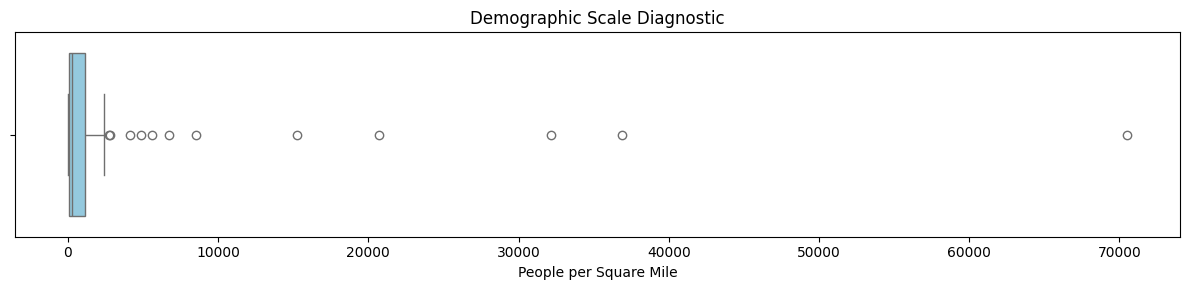

In [9]:
plt.figure(figsize=(12, 3))

# Generate the actual boxplot inside the figure container
sns.boxplot(x=df['pop_density'], color="skyblue")

plt.title("Demographic Scale Diagnostic")
plt.xlabel("People per Square Mile")
plt.tight_layout()
plt.show()

# Run this line to save the graph to outputs folder
# plt.savefig(str(output_dir / "boxplot_population_density.png"), dpi=300)

In [10]:
# Special check for Population Density (historically heavily skewed by NYC)
density_skew = df['pop_density'].skew()
print(f"Population Density Skewness: {density_skew:.2f}")

Population Density Skewness: 5.61


***RECOMMENDATION***: `pop_density` is highly right-skewed. **Log-transform it before PCA**.

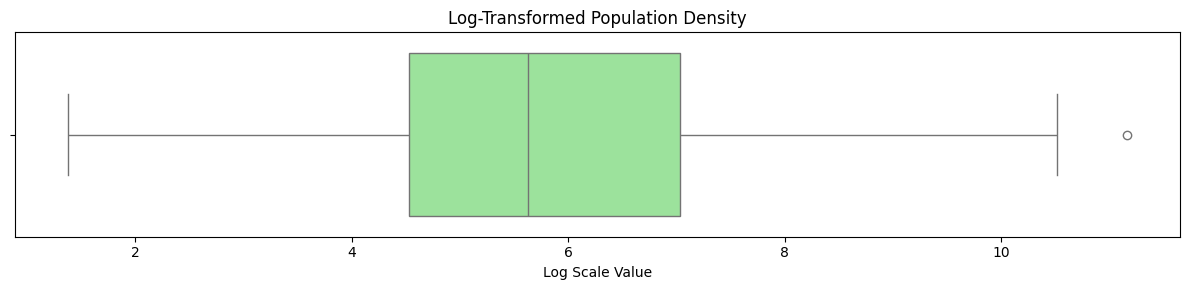

Log-Transformed Density Skewness: 0.69


In [11]:
# Check log-transformation for PCA stabilization
plt.figure(figsize=(12, 3))
sns.boxplot(x=np.log1p(df['pop_density']), color="lightgreen")

plt.title("Log-Transformed Population Density")
plt.xlabel("Log Scale Value")
plt.tight_layout()
plt.show()

print(f"Log-Transformed Density Skewness: {np.log1p(df['pop_density']).skew():.2f}")

### Percentage Variables

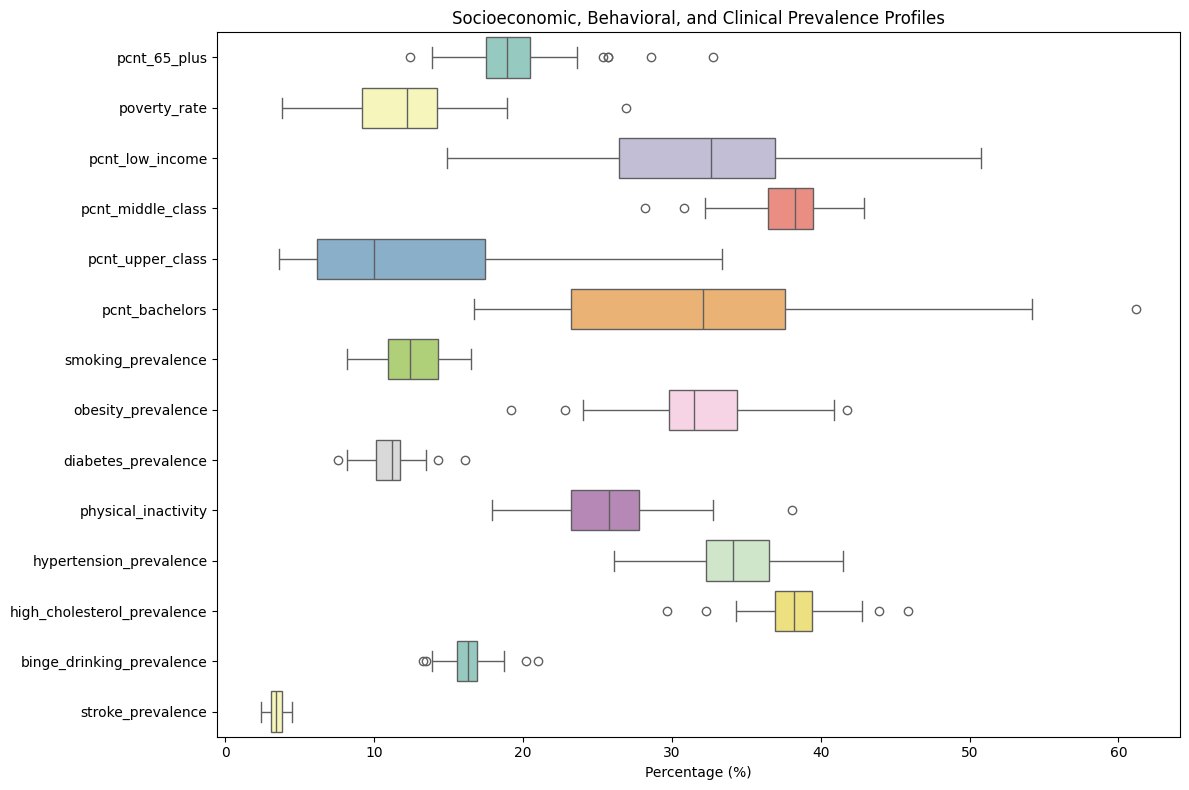

In [12]:
percentage_features = [col for col in all_features if col != 'pop_density']

plt.figure(figsize=(12, 8))
sns.boxplot(data=df[percentage_features], orient="h", palette="Set3")

plt.title("Socioeconomic, Behavioral, and Clinical Prevalence Profiles")
plt.xlabel("Percentage (%)")
plt.tight_layout()
plt.show()

# Run this line to save the graph to outputs folder
# plt.savefig(str(output_dir / "eda_percentage_features.png"), dpi=300)

**1. The Income Multi-Collinearity Proof**

Look at the distributions of the 3 class brackets:
- `pcnt_low_income` centers heavily between $25\%$ and $40\%$.
- `pcnt_middle_class` is incredibly tight, squeezed entirely between $35\%$ and $40\%$ with minimal variation across all 91 counties.
- `pcnt_upper_class` has a massive, wide-sweeping spread ranging from less than $5\%$ to nearly $35\%$.

Because these 3 metrics represent mutually exclusive bins that, alongside extreme poverty, sum up to approximately $100\%$ of a county's population. This creates a mandatory mathematical dependency (perfect multi-collinearity). Since `pcnt_middle_class` has virtually no variance across counties, it adds nothing but mathematical noise to a PCA model.

***RECOMMENDATION***: Omit `pcnt_middle_class` and `pcnt_upper_class` from the final SRI variable list. Retain only `pcnt_low_income` (and `poverty_rate`) to capture true economic deficit.

**2. High Baseline Prevalence Clustering**

Notice how `hypertension_prevalence` and `high_cholesterol_prevalence` share nearly identical median lines (around $35\%–38\%$) and very similar bounding shapes. This strongly points to a high pairwise correlation ($r$) between these two clinical precursors. 

***RECOMMENDATION***: Flags for the Correlation Heatmap Audit.

**3. Behavioral and Baseline Stability**

Core health factors such as `smoking_prevalence` and `stroke_prevalence` exhibit compact, symmetrical, and unskewed distributions without massive outlying tails.

***RECOMMENDATION***: These are high-quality PCA inputs. They do not require any non-linear pre-transformations (such as log-scaling). These variables are exceptionally well-suited for Z-score standardization before executing PCA.

## Correlation Matrix

In [13]:
# Linear correlation to accute stroke mortality
acute_corr = df[all_features].corrwith(df['acute_stroke_mortality_per_100k']).sort_values(ascending=False)
display(acute_corr.to_frame(name='Pearson_r_to_Mortality'))

# Examine the exact mathematical dependency between the income brackets
display(df[['pcnt_low_income', 'pcnt_middle_class', 'pcnt_upper_class']].corr())

,Pearson_r_to_Mortality
hypertension_prevalence,0.572641
pcnt_65_plus,0.481840
pcnt_middle_class,0.472434
smoking_prevalence,0.447212
obesity_prevalence,0.442649
stroke_prevalence,0.430971
high_cholesterol_prevalence,0.310922
pcnt_low_income,0.258053
diabetes_prevalence,0.143374
physical_inactivity,0.078822


,pcnt_low_income,pcnt_middle_class,pcnt_upper_class
pcnt_low_income,1.000000,0.236836,-0.874933
pcnt_middle_class,0.236836,1.000000,-0.657781
pcnt_upper_class,-0.874933,-0.657781,1.000000


**1. Health Risk Factors**

`hypertension_prevalence` is the single strongest linear predictor of acute stroke mortality ($r = 0.57$) in the dataset, followed closely by age (`pcnt_65_plus` at $r = 0.48$). Conversely, clinical variables like diabetes_prevalence ($r = 0.14$) and physical_inactivity ($r = 0.08$) show surprisingly weak linear relationships to the mortality target.

***RECOMMENDATION***: Do not drop the lower-correlated clinical variables (like diabetes) yet, as PCA might still capture their variance across columns.

**2. Education and Urban Factors**

Both `pcnt_bachelors` ($r = -0.41$) and `pop_density` ($r = -0.43$) show strong negative correlations with stroke mortality. This means that as higher education and population density increase, stroke mortality decreases.

***RECOMMENDATION***: Keep `pcnt_bachelors` and `pop_density` (log-transformed) in the pipeline, but ensure directional alignment. Because PCA blends variables based on variance, we must make sure the pipeline code "flips" these negative loadings so they don't accidentally mask vulnerability.

**3. The Income Bin Multicollinearity & Correlation to Stroke Mortality**

The pairwise correlation matrix at the bottom shows a massive negative correlation ($r = -0.87$) between `pcnt_low_income` and `pcnt_upper_class`. This proves they are mirror images of the exact same economic spectrum.

Furthermore, looking at the mortality correlations, `pcnt_middle_class` has a strong positive correlation with stroke mortality ($r = 0.47$), while `pcnt_low_income` has a much weaker positive correlation ($r = 0.26$), and `poverty_rate` is essentially flat ($r = -0.02$). This happens because the most affluent counties have tiny low-income populations, forcing the middle-class percentage mathematically higher in areas that are still structurally distinct from elite, high-income wealth centers.

***RECOMMENDATION***: Omit `pcnt_middle_class` and `pcnt_upper_class` entirely.